<a href="https://colab.research.google.com/github/mullinskatie7-source/katherine-mullins.github.io/blob/main/Katherine_Mullins_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Markdown
# Memo to Administration
**Date:** September 28, 2026  

**To:** Company Administration  

**From:** Katherine Mullins

**Subject:** Concerns with Customer Satisfaction Survey

The company's recent survey reported that 350 out of 500 users (70%) were satisfied with the new software update. Using this sample, the calculated confidence intervals were 66.63%–73.37% at 90% confidence, 65.98%–74.02% at 95% confidence, and 64.72%–75.28% at 99% confidence.

However, an independent agency surveyed another 500 users and reported that only 150 (30%) were satisfied. Its approximate 95% confidence interval was 25.98%–34.02%. The substantial difference between these results raises concerns about the accuracy and representativeness of the original survey, particularly because its satisfaction rating has been used in advertising.

**Recommendations**

I recommend reviewing both surveys to determine whether they used comparable sampling methods, populations, questions, and collection dates. Particular attention should be given to potential selection bias, nonresponse bias, and differences in how satisfaction was measured.

The company should temporarily suspend advertising claims based on the original satisfaction rating until the discrepancy is investigated. A new independently administered survey using standardized questions and a representative random sample would help establish a more reliable satisfaction estimate.

**Conclusion**

The difference between the two surveys is too substantial to attribute to ordinary random sampling variation under comparable survey conditions. Further investigation is necessary before either satisfaction estimate can be used confidently for business decisions or advertising.

**Signed,**  
Katherine Mullins

90% CI: 66.63% to 73.37%
95% CI: 65.98% to 74.02%
99% CI: 64.72% to 75.28%
Agency 95% CI: 25.98% to 34.02%


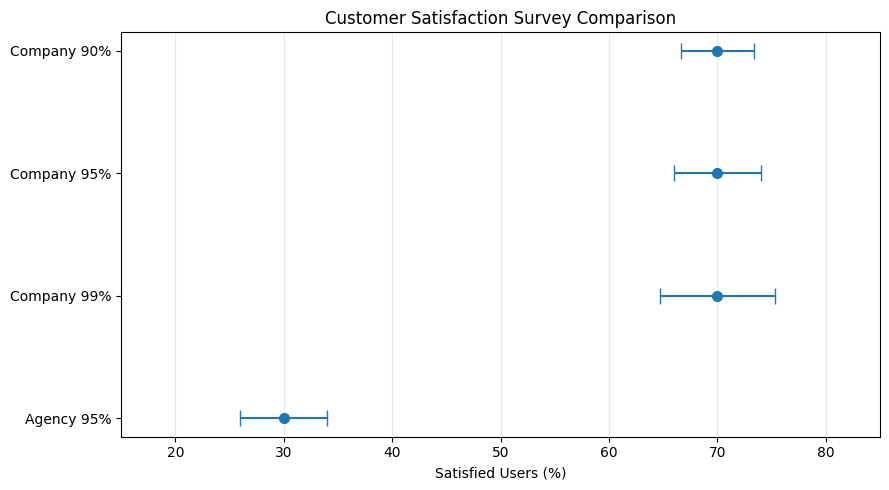

In [1]:
# Step 2: Import required modules and define constants

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Step 3: Survey results
n1, x1 = 500, 350
n2, x2 = 500, 150

p1 = x1 / n1
p2 = x2 / n2

def confidence_interval(p, n, confidence):
    z = norm.ppf(1 - (1 - confidence) / 2)
    se = np.sqrt(p * (1 - p) / n)
    margin = z * se
    return p - margin, p + margin

# Step 4: Calculate confidence intervals
levels = [0.90, 0.95, 0.99]

company_intervals = [
    confidence_interval(p1, n1, level)
    for level in levels
]

agency_interval = confidence_interval(p2, n2, 0.95)

for level, (lower, upper) in zip(
    levels, company_intervals
):
    print(
        f"{level:.0%} CI: "
        f"{lower:.2%} to {upper:.2%}"
    )

print(
    "Agency 95% CI:",
    f"{agency_interval[0]:.2%} to "
    f"{agency_interval[1]:.2%}"
)

# Step 5: Confidence interval comparison
labels = [
    "Company 90%",
    "Company 95%",
    "Company 99%",
    "Agency 95%"
]

points = np.array([p1, p1, p1, p2]) * 100

intervals = company_intervals + [agency_interval]

lower_errors = [
    (p - lower) * 100
    for p, (lower, upper) in zip(
        [p1, p1, p1, p2], intervals
    )
]

upper_errors = [
    (upper - p) * 100
    for p, (lower, upper) in zip(
        [p1, p1, p1, p2], intervals
    )
]

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(labels))

ax.errorbar(
    points,
    y,
    xerr=[lower_errors, upper_errors],
    fmt="o",
    capsize=6,
    markersize=7
)

ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlim(15, 85)
ax.set_xlabel("Satisfied Users (%)")
ax.set_title("Customer Satisfaction Survey Comparison")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("survey_comparison.png", dpi=200)
plt.show()